**Run note:** execute this notebook's first setup/code cell before any later cells. Each notebook is designed to run independently and re-detect the dataset path on its own.

# 08 â€” Training Pipeline

Trains the full model and saves checkpoints. All code is self-contained â€” model classes defined inline.

Trains:
1. Cross-attention fusion (main model)
2. Image-only ablation
3. Text-only ablation
4. Late fusion ablation

Logs all results to `/kaggle/working/training_history.json`.

In [9]:
import os
import json
import re
import time
import random
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from PIL import Image
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.cuda.amp import autocast, GradScaler
from sklearn.metrics import roc_auc_score, f1_score
from transformers import CLIPModel, CLIPProcessor

ON_KAGGLE = Path("/kaggle/input").is_dir()
JSONL_CANDIDATES = {
    "train": ["train.jsonl"],
    "dev": ["dev.jsonl", "dev_seen.jsonl", "dev_unseen.jsonl"],
    "test": ["test.jsonl", "test_seen.jsonl", "test_unseen.jsonl"],
}
IMAGE_DIR_CANDIDATES = ("img", "images")


def _has_image_dir(path: Path) -> bool:
    return any((path / name).is_dir() for name in IMAGE_DIR_CANDIDATES)


def _has_any_jsonl(path: Path, names) -> bool:
    return any((path / name).is_file() for name in names)


def _looks_like_dataset_root(path: Path) -> bool:
    return path.is_dir() and _has_image_dir(path) and _has_any_jsonl(path, JSONL_CANDIDATES["train"])


def detect_data_dir():
    for env_name in ("KAGGLE_DATA_DIR", "META_HATEFUL_MEME_DATA_DIR"):
        env_dir = os.environ.get(env_name, "").strip()
        if env_dir and _looks_like_dataset_root(Path(env_dir)):
            return Path(env_dir), f"env:{env_name}"

    kaggle_input = Path("/kaggle/input")
    default_candidate = kaggle_input / "meta-hateful-meme-detection" / "data"
    if _looks_like_dataset_root(default_candidate):
        return default_candidate, "default:/kaggle/input/meta-hateful-meme-detection/data"

    if ON_KAGGLE:
        for train_jsonl in sorted(kaggle_input.rglob("train.jsonl")):
            candidate = train_jsonl.parent
            if _looks_like_dataset_root(candidate):
                return candidate, f"auto:{candidate}"

        for candidate in sorted(kaggle_input.rglob("*")):
            if candidate.is_dir() and _looks_like_dataset_root(candidate):
                return candidate, f"auto:{candidate}"

    for candidate in (Path.cwd() / "data", Path.cwd().parent / "data", Path.cwd(), Path.cwd().parent):
        if _looks_like_dataset_root(candidate):
            return candidate, f"local:{candidate}"

    return None, "not-found"


def resolve_split(base_dir, names):
    base_dir = Path(base_dir)
    for name in names:
        path = base_dir / name
        if path.is_file():
            return path
    for name in names:
        matches = sorted(base_dir.rglob(name))
        if matches:
            return matches[0]
    return None


DATA_DIR, data_source = detect_data_dir()
if DATA_DIR is None:
    raise FileNotFoundError(
        "Dataset not found. Set KAGGLE_DATA_DIR or META_HATEFUL_MEME_DATA_DIR to the folder containing train.jsonl and img/."
    )

IMG_DIR = next((DATA_DIR / name for name in IMAGE_DIR_CANDIDATES if (DATA_DIR / name).is_dir()), None)
TRAIN_PATH = resolve_split(DATA_DIR, JSONL_CANDIDATES["train"])
DEV_PATH = resolve_split(DATA_DIR, JSONL_CANDIDATES["dev"])
OUTPUT_DIR = Path("/kaggle/working") if ON_KAGGLE else Path.cwd() / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

if TRAIN_PATH is None or DEV_PATH is None:
    raise FileNotFoundError(f"Expected train/dev splits under {DATA_DIR}")

DATA_DIR = str(DATA_DIR)
IMG_DIR = str(IMG_DIR) if IMG_DIR is not None else None
TRAIN_PATH = str(TRAIN_PATH)
DEV_PATH = str(DEV_PATH)
OUTPUT_DIR = str(OUTPUT_DIR)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SEED = 42

print(f"Using DATA_DIR : {DATA_DIR}")
print(f"Using IMG_DIR  : {IMG_DIR}")
print(f"Using source   : {data_source}")
print(f"Output dir     : {OUTPUT_DIR}")
print(f"Device         : {DEVICE}")


def set_seeds(s=SEED):
    random.seed(s)
    np.random.seed(s)
    torch.manual_seed(s)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(s)


set_seeds()

CFG = {
    "batch_size": 32,
    "epochs": 10,
    "lr": 1e-4,
    "weight_decay": 0.01,
    "warmup_steps": 100,
    "embed_dim": 512,
    "num_heads": 4,
    "dropout": 0.3,
    "focal_gamma": 2.0,
    "class_weights": [1.0, 1.786],
    "clip_model": "openai/clip-vit-base-patch32",
    "max_text_len": 77,
    "grad_clip": 1.0,
}

print("Config:", CFG)
print(f"Device: {DEVICE}")

Using DATA_DIR : /kaggle/input/datasets/muddybuddy/meta-hateful-meme-detection/data
Using IMG_DIR  : /kaggle/input/datasets/muddybuddy/meta-hateful-meme-detection/data/img
Using source   : auto:/kaggle/input/datasets/muddybuddy/meta-hateful-meme-detection/data
Output dir     : /kaggle/working
Device         : cuda
Config: {'batch_size': 32, 'epochs': 10, 'lr': 0.0001, 'weight_decay': 0.01, 'warmup_steps': 100, 'embed_dim': 512, 'num_heads': 4, 'dropout': 0.3, 'focal_gamma': 2.0, 'class_weights': [1.0, 1.786], 'clip_model': 'openai/clip-vit-base-patch32', 'max_text_len': 77, 'grad_clip': 1.0}
Device: cuda


In [10]:
from pathlib import Path


def resolve_image_path(data_dir, image_ref):
    data_dir = Path(data_dir)
    image_ref = Path(str(image_ref))

    candidates = []
    if image_ref.is_absolute():
        candidates.append(image_ref)

    candidates.extend([
        data_dir / image_ref,
        data_dir.parent / image_ref,
    ])

    if image_ref.parts:
        if image_ref.parts[0] in {"img", "images"} and len(image_ref.parts) > 1:
            stripped = Path(*image_ref.parts[1:])
            candidates.extend([
                data_dir / stripped,
                data_dir.parent / stripped,
            ])
        elif image_ref.parts[0] not in {"img", "images"}:
            candidates.extend([
                data_dir / "img" / image_ref,
                data_dir / "images" / image_ref,
                data_dir.parent / "img" / image_ref,
                data_dir.parent / "images" / image_ref,
            ])

    seen = set()
    for candidate in candidates:
        key = str(candidate)
        if key in seen:
            continue
        seen.add(key)
        if candidate.exists():
            return candidate

    raise FileNotFoundError(f"Could not find image '{image_ref}' relative to {data_dir}")

In [11]:
def load_jsonl(path):
    with open(path, encoding="utf-8") as f:
        return pd.DataFrame([json.loads(l) for l in f])


def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = re.sub(r"https?://\S+", " ", text)
    text = re.sub(r"@\w+", " ", text)
    text = re.sub(r"#(\w+)", r" \1 ", text)
    return re.sub(r"\s+", " ", text).strip() or "[no text]"


train_df = load_jsonl(TRAIN_PATH)
dev_df = load_jsonl(DEV_PATH)
for df in [train_df, dev_df]:
    df["clean_text"] = df["text"].apply(clean_text)

print(f"Train={len(train_df)}, Dev={len(dev_df)}")

Train=8500, Dev=500


In [12]:
#  Dataset 
class MemeDataset(Dataset):
    def __init__(self, df, data_dir, processor):
        self.df        = df.reset_index(drop=True)
        self.data_dir  = data_dir
        self.processor = processor
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        try:
            img = Image.open(resolve_image_path(self.data_dir, row["img"])).convert("RGB")
        except:
            img = Image.new("RGB", (224, 224), 128)
        text = str(row.get("clean_text", row["text"]))
        enc  = self.processor(text=[text], images=img, return_tensors="pt",
                               padding="max_length", max_length=CFG["max_text_len"], truncation=True)
        lbl  = int(row["label"]) if "label" in row else -1
        return {
            "pixel_values" : enc["pixel_values"].squeeze(0),
            "input_ids"    : enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "label"        : torch.tensor(lbl, dtype=torch.long),
        }

processor  = CLIPProcessor.from_pretrained(CFG["clip_model"])
train_ds   = MemeDataset(train_df, DATA_DIR, processor)
dev_ds     = MemeDataset(dev_df,   DATA_DIR, processor)

# Weighted random sampler for class balance
labels     = train_df["label"].values
n_hat      = (labels == 1).sum()
n_ben      = (labels == 0).sum()
w0, w1     = len(labels) / (2.0 * n_ben), len(labels) / (2.0 * n_hat)
sample_w   = [w0 if l == 0 else w1 for l in labels]
sampler    = WeightedRandomSampler(sample_w, len(sample_w), replacement=True)

train_loader = DataLoader(train_ds, batch_size=CFG["batch_size"], sampler=sampler,  num_workers=2, pin_memory=True)
dev_loader   = DataLoader(dev_ds,   batch_size=CFG["batch_size"] * 2, shuffle=False, num_workers=2, pin_memory=True)

print(f"Train batches: {len(train_loader)}, Dev batches: {len(dev_loader)}")

Train batches: 266, Dev batches: 8


In [13]:
# ── Model definitions ─────────────────────────────────────────────────

def _ensure_tensor(out):
    """Extract tensor from model output if it returns a dataclass instead of a plain tensor."""
    if isinstance(out, torch.Tensor):
        return out
    if hasattr(out, "pooler_output") and out.pooler_output is not None:
        return out.pooler_output
    if hasattr(out, "last_hidden_state"):
        return out.last_hidden_state[:, 0]
    return out[0]

class CLIPEncoder(nn.Module):
    def __init__(self, model_name=CFG["clip_model"]):
        super().__init__()
        self.clip = CLIPModel.from_pretrained(model_name)
        for p in self.clip.parameters(): p.requires_grad_(False)
    def forward(self, pixel_values, input_ids, attention_mask):
        i = F.normalize(_ensure_tensor(self.clip.get_image_features(pixel_values=pixel_values)), dim=-1)
        t = F.normalize(_ensure_tensor(self.clip.get_text_features(input_ids=input_ids, attention_mask=attention_mask)), dim=-1)
        return i, t

class CrossAttentionFusion(nn.Module):
    def __init__(self, d=512, heads=4, drop=0.1):
        super().__init__()
        self.i2t = nn.MultiheadAttention(d, heads, dropout=drop, batch_first=True)
        self.t2i = nn.MultiheadAttention(d, heads, dropout=drop, batch_first=True)
        self.ni  = nn.LayerNorm(d)
        self.nt  = nn.LayerNorm(d)
    def forward(self, i, t):
        is_ = i.unsqueeze(1); ts = t.unsqueeze(1)
        ic, ia = self.i2t(is_, ts, ts)
        tc, ta = self.t2i(ts, is_, is_)
        return torch.cat([self.ni(i + ic.squeeze(1)), self.nt(t + tc.squeeze(1))], -1), ia, ta

class ClassificationHead(nn.Module):
    def __init__(self, d=1024, drop=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d, 256), nn.GELU(), nn.Dropout(drop),
            nn.Linear(256, 128), nn.GELU(), nn.Dropout(drop),
            nn.Linear(128, 2)
        )
    def forward(self, x): return self.net(x)

class HatefulMemeClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = CLIPEncoder()
        self.fusion  = CrossAttentionFusion(CFG["embed_dim"], CFG["num_heads"])
        self.head    = ClassificationHead(CFG["embed_dim"] * 2)
    def forward(self, pixel_values, input_ids, attention_mask):
        i, t = self.encoder(pixel_values, input_ids, attention_mask)
        fused, ia, ta = self.fusion(i, t)
        return self.head(fused), ia, ta

# Ablation variants
class ImageOnlyClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.clip = CLIPModel.from_pretrained(CFG["clip_model"])
        for p in self.clip.parameters(): p.requires_grad_(False)
        self.head = nn.Sequential(nn.Linear(512, 256), nn.GELU(), nn.Dropout(0.3),
                                   nn.Linear(256, 2))
    def forward(self, pixel_values, input_ids, attention_mask):
        f = F.normalize(_ensure_tensor(self.clip.get_image_features(pixel_values=pixel_values)), -1)
        return self.head(f), None, None

class TextOnlyClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.clip = CLIPModel.from_pretrained(CFG["clip_model"])
        for p in self.clip.parameters(): p.requires_grad_(False)
        self.head = nn.Sequential(nn.Linear(512, 256), nn.GELU(), nn.Dropout(0.3),
                                   nn.Linear(256, 2))
    def forward(self, pixel_values, input_ids, attention_mask):
        f = F.normalize(_ensure_tensor(self.clip.get_text_features(input_ids=input_ids, attention_mask=attention_mask)), -1)
        return self.head(f), None, None

class LateFusionClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.clip = CLIPModel.from_pretrained(CFG["clip_model"])
        for p in self.clip.parameters(): p.requires_grad_(False)
        self.head = nn.Sequential(nn.Linear(1024, 512), nn.GELU(), nn.Dropout(0.3),
                                   nn.Linear(512, 128), nn.GELU(), nn.Linear(128, 2))
    def forward(self, pixel_values, input_ids, attention_mask):
        i = F.normalize(_ensure_tensor(self.clip.get_image_features(pixel_values=pixel_values)), -1)
        t = F.normalize(_ensure_tensor(self.clip.get_text_features(input_ids=input_ids, attention_mask=attention_mask)), -1)
        return self.head(torch.cat([i, t], -1)), None, None

print("All model classes defined.")

All model classes defined.


In [14]:
# â”€â”€ Weighted Focal Loss â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
class WeightedFocalLoss(nn.Module):
    def __init__(self, gamma=2.0, class_weights=None):
        super().__init__()
        self.gamma = gamma
        self.register_buffer("w", torch.tensor(class_weights or [1.0, 1.0]))
    def forward(self, logits, targets):
        ce   = F.cross_entropy(logits, targets, weight=self.w, reduction="none")
        pt   = torch.exp(-ce)
        return ((1 - pt) ** self.gamma * ce).mean()

# â”€â”€ LR warmup scheduler â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
def get_cosine_schedule_with_warmup(optimizer, warmup_steps, total_steps):
    import math
    def lr_lambda(step):
        if step < warmup_steps:
            return step / max(1, warmup_steps)
        progress = (step - warmup_steps) / max(1, total_steps - warmup_steps)
        return max(0.0, 0.5 * (1.0 + math.cos(math.pi * progress)))
    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

print("Loss and scheduler ready.")

Loss and scheduler ready.


In [15]:
# ── Training loop ─────────────────────────────────────────────────────
def train_model(model, name, epochs=CFG["epochs"]):
    model = model.to(DEVICE)
    trainable_params = [p for p in model.parameters() if p.requires_grad]
    optimizer = torch.optim.AdamW(trainable_params, lr=CFG["lr"], weight_decay=CFG["weight_decay"])
    total_steps  = len(train_loader) * epochs
    scheduler    = get_cosine_schedule_with_warmup(optimizer, CFG["warmup_steps"], total_steps)
    criterion    = WeightedFocalLoss(CFG["focal_gamma"], CFG["class_weights"]).to(DEVICE)
    scaler       = GradScaler(enabled=(DEVICE == "cuda"))

    best_auroc = 0.0
    history    = {"train_loss": [], "val_auroc": [], "val_f1": []}

    for epoch in range(epochs):
        # ── Train ──
        model.train()
        epoch_loss = 0.0
        t0 = time.time()
        for batch in train_loader:
            pv   = batch["pixel_values"].to(DEVICE)
            ids  = batch["input_ids"].to(DEVICE)
            mask = batch["attention_mask"].to(DEVICE)
            lbls = batch["label"].to(DEVICE)
            optimizer.zero_grad()
            with autocast(enabled=(DEVICE == "cuda")):
                logits, _, _ = model(pv, ids, mask)
                loss = criterion(logits, lbls)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(trainable_params, CFG["grad_clip"])
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
            epoch_loss += loss.item()

        # ── Validate ──
        model.eval()
        all_probs, all_preds, all_labs = [], [], []
        with torch.no_grad():
            for batch in dev_loader:
                pv   = batch["pixel_values"].to(DEVICE)
                ids  = batch["input_ids"].to(DEVICE)
                mask = batch["attention_mask"].to(DEVICE)
                lbls = batch["label"]
                logits, _, _ = model(pv, ids, mask)
                logits = logits.float()  # cast to fp32 to avoid NaN from mixed precision
                probs = torch.softmax(logits, -1)[:, 1].cpu().numpy()
                preds = logits.argmax(-1).cpu().numpy()
                all_probs.extend(probs); all_preds.extend(preds); all_labs.extend(lbls.numpy())

        # Safety: replace any residual NaN with 0.5
        all_probs = np.array(all_probs, dtype=np.float64)
        nan_mask = np.isnan(all_probs)
        if nan_mask.any():
            print(f"  ⚠ {nan_mask.sum()} NaN probs replaced with 0.5")
            all_probs[nan_mask] = 0.5

        auroc = roc_auc_score(all_labs, all_probs)
        f1    = f1_score(all_labs, all_preds, pos_label=1)
        avg_loss = epoch_loss / len(train_loader)
        elapsed  = time.time() - t0

        history["train_loss"].append(avg_loss)
        history["val_auroc"].append(auroc)
        history["val_f1"].append(f1)

        print(f"[{name}] Ep {epoch+1:02d}/{epochs}  loss={avg_loss:.4f}  "
              f"AUROC={auroc:.4f}  F1={f1:.4f}  ({elapsed:.0f}s)")

        # Save best checkpoint
        if auroc > best_auroc:
            best_auroc = auroc
            ckpt_path  = os.path.join(OUTPUT_DIR, f"{name}_best.pt")
            torch.save(model.state_dict(), ckpt_path)
            print(f"  => New best AUROC {best_auroc:.4f} saved to {ckpt_path}")

    # Save history
    hist_path = os.path.join(OUTPUT_DIR, f"{name}_history.json")
    with open(hist_path, "w") as f:
        json.dump(history, f)

    return history, best_auroc

print("Training function ready.")

Training function ready.


In [16]:
# â”€â”€ Run training â€” all 4 variants â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
# Estimated training time per variant on T4 GPU:
#   cross_attention: ~15 min  |  ablations: ~10 min each

variants = [
    ("cross_attention",  HatefulMemeClassifier),
    ("image_only",       ImageOnlyClassifier),
    ("text_only",        TextOnlyClassifier),
    ("late_fusion",      LateFusionClassifier),
]

all_histories = {}
for var_name, ModelClass in variants:
    print(f"\n{'='*55}")
    print(f"Training: {var_name}")
    print(f"{'='*55}")
    set_seeds()
    model = ModelClass()
    hist, best = train_model(model, var_name)
    all_histories[var_name] = hist
    del model
    torch.cuda.empty_cache()
    print(f"Best AUROC for {var_name}: {best:.4f}")

# Save aggregated history
with open(os.path.join(OUTPUT_DIR, "training_history.json"), "w") as f:
    json.dump(all_histories, f)
print("\nAll training complete!")


Training: cross_attention


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
/tmp/ipykernel_55/49692649.py:9: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler       = GradScaler(enabled=(DEVICE == "cuda"))
/tmp/ipykernel_55/49692649.py:25: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(DEVICE == "cuda")):


[cross_attention] Ep 01/10  loss=0.2989  AUROC=0.6574  F1=0.6861  (149s)
  => New best AUROC 0.6574 saved to /kaggle/working/cross_attention_best.pt


/tmp/ipykernel_55/49692649.py:25: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(DEVICE == "cuda")):


...

[late_fusion] Ep 08/10  loss=nan  AUROC=0.5178  F1=0.0956  (147s)


/tmp/ipykernel_55/49692649.py:25: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(DEVICE == "cuda")):


[late_fusion] Ep 09/10  loss=nan  AUROC=0.5178  F1=0.0956  (173s)


/tmp/ipykernel_55/49692649.py:25: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(DEVICE == "cuda")):


[late_fusion] Ep 10/10  loss=nan  AUROC=0.5178  F1=0.0956  (178s)
Best AUROC for late_fusion: 0.5178

All training complete!


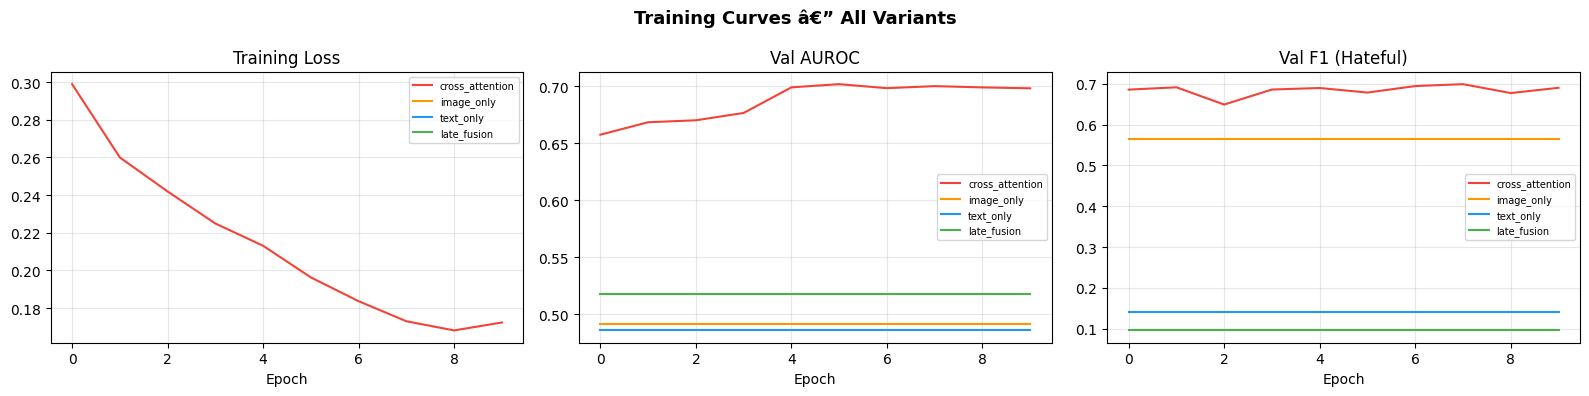

Training notebook complete. Proceed to notebook 09 (Evaluation).


In [ ]:
# ── Training curves ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
colors = {"cross_attention": "#F44336", "image_only": "#FF9800",
          "text_only": "#2196F3", "late_fusion": "#4CAF50"}

for name, hist in all_histories.items():
    c = colors.get(name, "gray")
    axes[0].plot(hist["train_loss"], label=name, color=c)
    axes[1].plot(hist["val_auroc"],  label=name, color=c)
    axes[2].plot(hist["val_f1"],     label=name, color=c)

axes[0].set_title("Training Loss");  axes[0].set_xlabel("Epoch")
axes[1].set_title("Val AUROC");      axes[1].set_xlabel("Epoch")
axes[2].set_title("Val F1 (Hateful)"); axes[2].set_xlabel("Epoch")

for ax in axes:
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)

plt.suptitle("Training Curves — All Variants", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "training_curves.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Training notebook complete. Proceed to notebook 09 (AUROC Optimization) or notebook 10 (Evaluation).")